# Student Registration 분석

## 1. 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

In [11]:
# 폰트 테마 설정
sns.set_theme(style="whitegrid")
# 한글 폰트 설정 (맑은 고딕) — set_theme 이후에 지정해야 덮어쓰이지 않음
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [2]:
student_re = pd.read_csv("../CSV_files/studentRegistration.csv")
student_re.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [3]:
student_re.describe()

,id_student,date_registration,date_unregistration
count,3.259300e+04,32548.000000,10072.000000
mean,7.066877e+05,-69.411300,49.757645
std,5.491673e+05,49.260522,82.460890
min,3.733000e+03,-322.000000,-365.000000
25%,5.085730e+05,-100.000000,-2.000000
50%,5.903100e+05,-57.000000,27.000000
75%,6.444530e+05,-29.000000,109.000000
max,2.716795e+06,167.000000,444.000000


In [4]:
student_re.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB


In [5]:
student_re.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64

In [6]:
cat_cols = ["code_module", "code_presentation", "date_registration", "date_unregistration"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(student_re[c].value_counts(dropna=False), "\n")

--- code_module ---
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64 

--- code_presentation ---
code_presentation
2014J    11260
2013J     8845
2014B     7804
2013B     4684
Name: count, dtype: int64 

--- date_registration ---
date_registration
-22.0     1034
-29.0      982
-24.0      741
-25.0      730
-23.0      729
          ... 
-275.0       1
 83.0        1
 40.0        1
 18.0        1
 110.0       1
Name: count, Length: 333, dtype: int64 

--- date_unregistration ---
date_unregistration
 NaN      22521
 12.0       788
 0.0        419
 27.0       170
-1.0        147
          ...  
 444.0        1
-62.0         1
-297.0        1
-365.0        1
-112.0        1
Name: count, Length: 417, dtype: int64 



## 1-1. label_churn 정의 (01번 노트북과 동일한 기준)

이후 분석에서 01_Student_info_EDA.ipynb와 같은 기준으로 이탈 여부를 비교하려면
label_churn 정의를 먼저 통일해둬야 합니다. 그래서 이 노트북에서도 studentInfo.csv를 불러와
동일한 규칙(Withdrawn=이탈, 나머지=완수)으로 label_churn을 만들어두고, 앞으로의 조인/분석에서
계속 재사용합니다.

In [7]:
# studentInfo.csv를 불러옵니다. (이 노트북에서 처음 불러오는 것이라, 이후 2번 조인에서도 이 info를 그대로 재사용합니다)
info = pd.read_csv("../CSV_files/studentInfo.csv")

# 01_Student_info_EDA.ipynb와 동일한 기준으로 이탈 여부를 정의합니다.
# 훈련 결과가 'Withdrawn'이면 "이탈", 나머지(Pass/Fail/Distinction)는 "완수"로 분류합니다.
# (조기 이탈률만 확인하기 위해 Fail도 일단 "완수"로 분류)
info["label_churn"] = info["final_result"].apply(lambda x: "이탈" if x == "Withdrawn" else "완수")

# 결과가 어떻게 나뉘었는지 퍼센트로 확인합니다. (01번 노트북과 같은 값(완수 0.688 / 이탈 0.312)이 나와야 정상입니다)
print(info["label_churn"].value_counts(normalize=True).round(3))

label_churn
완수    0.688
이탈    0.312
Name: proportion, dtype: float64


## 2. 라벨 정합성 검증 (studentInfo와 조인)

studentInfo.csv에서 `final_result == "Withdrawn"`인 학생과, 이 파일의 `date_unregistration`이
있는 학생은 둘 다 "이탈"을 나타내는 값이므로 원래는 정확히 같은 사람들이어야 합니다.
그런데 위에서 본 것처럼 Withdrawn은 10,156명, date_unregistration이 있는 학생은 10,072명으로
84명 차이가 납니다. 두 라벨이 정말 같은 대상을 가리키는지 직접 조인해서 확인합니다.

In [8]:
# 1-1에서 이미 불러온 info(studentInfo.csv)를 그대로 재사용해서,
# (code_module, code_presentation, id_student) 키로 student_re와 조인합니다.
# 이 3개 컬럼을 합치면 "어떤 학생이 어떤 과목/학기를 수강했는지"를 유일하게 식별할 수 있습니다.
merged = pd.merge(
    info, student_re,
    on=["code_module", "code_presentation", "id_student"],
    how="left"  # info 기준으로 붙여서, info의 학생이 하나도 빠지지 않게 합니다.
)

is_withdrawn = merged["final_result"] == "Withdrawn"
has_unreg_date = merged["date_unregistration"].notna()

print("final_result == Withdrawn 인원:", is_withdrawn.sum())
print("date_unregistration 값이 있는 인원:", has_unreg_date.sum())

# Case A: "Withdrawn"이라고 표시됐는데 이탈 날짜 기록이 없는 학생
case_a = merged[is_withdrawn & ~has_unreg_date]
# Case B: Withdrawn이 아닌데 이탈 날짜가 기록된 학생
case_b = merged[~is_withdrawn & has_unreg_date]

print(f"\nWithdrawn인데 date_unregistration이 없는 경우: {len(case_a)}건")
print(case_a["final_result"].value_counts())

print(f"\nWithdrawn이 아닌데 date_unregistration이 있는 경우: {len(case_b)}건")
print(case_b["final_result"].value_counts())

# [검산] 10,156(Withdrawn) - 93(case_a) + 9(case_b) = 10,072 -> 처음 봤던 84명 차이가 이렇게 설명됩니다.

final_result == Withdrawn 인원: 10156
date_unregistration 값이 있는 인원: 10072

Withdrawn인데 date_unregistration이 없는 경우: 93건
final_result
Withdrawn    93
Name: count, dtype: int64

Withdrawn이 아닌데 date_unregistration이 있는 경우: 9건
final_result
Fail    9
Name: count, dtype: int64


**[발견]**
- **93명**: `final_result="Withdrawn"`인데 `date_unregistration`이 비어 있습니다. 이탈 처리는 됐지만
  정확한 이탈 시점이 기록에서 누락된 케이스로 보입니다. 이 학생들은 "언제 이탈했는지"를 알 수 없으므로
  이후 이탈 시점 분석에서는 자동으로 제외됩니다.
- **9명**: `final_result="Fail"`인데 `date_unregistration`이 있습니다. 즉 중간에 수강을 취소했지만
  최종적으로는 이탈(Withdrawn)이 아니라 낙제(Fail)로 기록된 경우입니다. 학기가 끝날 무렵에야
  취소해서 이미 성적 처리가 진행된 케이스로 추정됩니다.
- 10,156 - 93 + 9 = 10,072 로 정확히 맞아떨어져서, 처음 봤던 84명 차이의 원인이 이 두 그룹임을 확인했습니다.

**[결론]** `label_churn`(final_result 기반)과 `date_unregistration`(날짜 기반)은 100% 일치하지 않습니다.
앞으로 "이탈 시점"을 분석할 때는 date_unregistration이 있는 10,072명을 기준으로 진행하되,
"이탈 여부" 자체를 판단할 때는 지금까지 써온 studentInfo의 final_result / label_churn 기준을 유지하는 게 안전합니다.

## 3. 이탈 시점(date_unregistration) 분포 분석

01번 노트북에서는 "이탈했는지 여부"만 알 수 있었고, "언제" 이탈했는지는 알 수 없었습니다.
이 프로젝트의 목표가 "조기 이탈률 개선"인 만큼, date_unregistration으로 실제 이탈 타이밍을
확인하는 게 이 파일의 핵심 가치입니다. date_unregistration은 강좌 시작일을 0일로 기준삼은
값이라, 음수면 강좌가 시작되기도 전에 이미 취소했다는 뜻입니다.

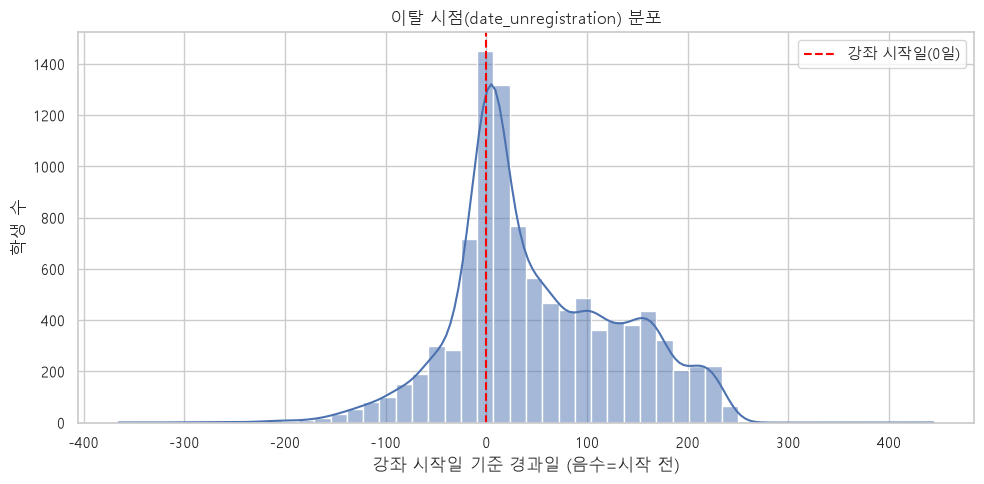

In [12]:
# 이탈 기록이 있는 학생만 대상으로 분포를 봅니다 (date_unregistration이 NaN인 학생은 이탈 안 한 학생).
plt.figure(figsize=(10, 5))
sns.histplot(merged["date_unregistration"].dropna(), bins=50, kde=True)

# 0일 = 강좌 시작일. 이 선을 기준으로 왼쪽(음수)은 "시작도 못 해보고 이탈"한 학생입니다.
plt.axvline(0, color="red", linestyle="--", label="강좌 시작일(0일)")
plt.title("이탈 시점(date_unregistration) 분포")
plt.xlabel("강좌 시작일 기준 경과일 (음수=시작 전)")
plt.ylabel("학생 수")
plt.legend()
plt.tight_layout()
plt.show()

date_unregistration
강좌 시작 전 이탈        2678
초반 조기이탈(0~30일)    2449
중후반 이탈(30일 초과)    4945
Name: count, dtype: int64

date_unregistration
강좌 시작 전 이탈        26.6%
초반 조기이탈(0~30일)    24.3%
중후반 이탈(30일 초과)    49.1%
Name: count, dtype: str


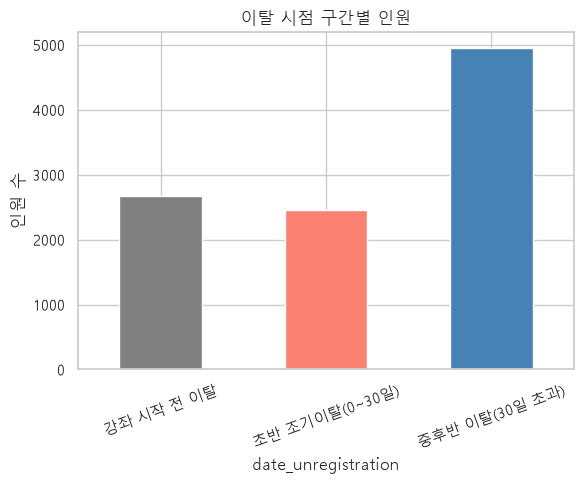

In [13]:
# 이탈 시점을 3개 구간으로 나눠서 각 구간에 몇 명이 있는지 세어봅니다.
unreg = merged["date_unregistration"].dropna()

def bucket(x):
    if x < 0:
        return "강좌 시작 전 이탈"      # 등록만 하고 강좌가 시작되기도 전에 취소
    elif x <= 30:
        return "초반 조기이탈(0~30일)"   # 강좌 시작 후 한 달 이내 이탈
    else:
        return "중후반 이탈(30일 초과)"  # 그 이후 이탈

order = ["강좌 시작 전 이탈", "초반 조기이탈(0~30일)", "중후반 이탈(30일 초과)"]
bucket_counts = unreg.apply(bucket).value_counts().reindex(order)
bucket_pct = (bucket_counts / len(unreg) * 100).round(1)

print(bucket_counts)
print()
print(bucket_pct.astype(str) + "%")

plt.figure(figsize=(6, 5))
bucket_counts.plot(kind="bar", color=["gray", "salmon", "steelblue"])
plt.title("이탈 시점 구간별 인원")
plt.ylabel("인원 수")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# [해석 포인트] "강좌 시작 전 이탈" + "초반 조기이탈"을 합치면 전체 이탈자의 절반(50.9%)입니다.
# 즉 이탈 원인의 개입 시점을 잡을 때, 강좌 중후반보다 등록 직후~시작 시점에 집중하는 게
# 훨씬 더 많은 이탈을 예방할 수 있다는 뜻입니다.